<h1><center>EIE 401 - PROCESAMIENTO DIGITAL MULTIMEDIA</center></h1>
<h2><center>Actividad Integrada: Fundamentos, Muestreo y Casos de Aplicación</center></h2>
<center><h3>Profesor: Jorge Cardenas</h3></center>
<center><h3>Estudiante: Javiera Vega Pino</h3></center>
<center><h5>Pontificia Universidad Católica de Valparaíso</h5></center>

## 1. Perfil Profesional y Repositorio
El uso de herramientas de control de versiones y repositorios públicos es esencial. 

**Tarea:** Agrega tu usuario de GitHub y el enlace al repositorio que utilizarás para este curso.

In [218]:
# Usuario GitHub: jaaavs
# Enlace Repositorio: https://github.com/jaaavs/EIE401

## 2. Configuración del Entorno y Librerías
Importamos las librerías base para procesamiento de señales, análisis estadístico y visualización.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq, fft2, fftshift, ifft2, ifftshift
import scipy.stats as stats

## 3. Distribuciones de Probabilidad y Ruido
En multimedia, el ruido no es solo 'error', es un fenómeno estocástico que puede modelarse matemáticamente.

**Tarea:**
1. Genera 10,000 muestras de una **Distribución Normal** (Gaussiana) con $\mu=0$ y $\sigma=1$. Grafica su histograma.
2. Crea una señal senoidal pura de 20 Hz.
3. Agrega el ruido gaussiano a la señal pura para obtener una señal contaminada.
4. Grafica la señal pura, el ruido solo, y la señal final resultante.

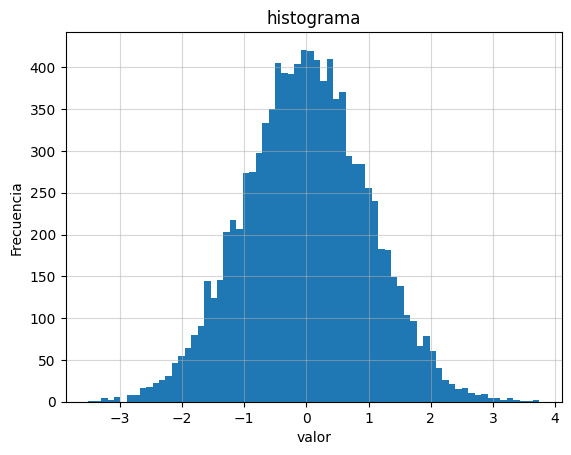

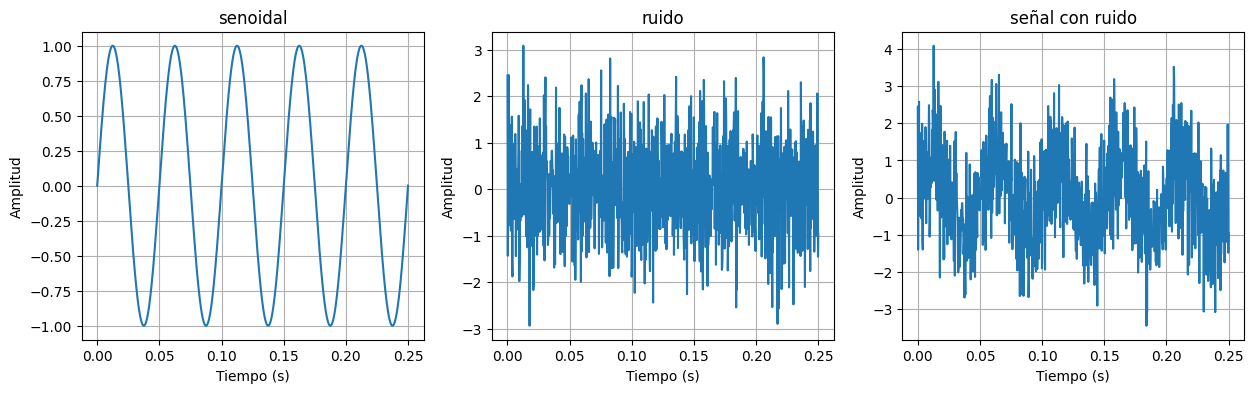

In [6]:
# Implementación de estadística y generación de 

#1
muestras= 10000
d_normal =np.random.normal(0,1,muestras)  #en orden: media, desviación estandar y las muestras

plt.figure()
plt.hist(d_normal, bins=70)
plt.title("histograma")
plt.xlabel('valor')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.5)
plt.show()

#2
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
f_muestreo= 1000
frecuencia= 20
rango = np.linspace(0,0.25,f_muestreo) #al variar el valor final del muestreo (0.1 o 0.5 o 1) se marcará más el efecto del ruido en la señal final, en este caso se usó 0.25
seno = np.sin(2*np.pi*frecuencia*rango) 
axes[0].plot(rango, seno)
axes[0].set_title("senoidal")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

#3
ruido = np.random.normal(0, 1, f_muestreo) #igual que en inciso 1 pero con menos muestras para no saturar el plot
axes[1].plot(rango, ruido)
axes[1].set_title("ruido")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Amplitud")
axes[1].grid(True)


#4
senal_final = seno + ruido
axes[2].plot(rango, senal_final)
axes[2].set_title("señal con ruido")
axes[2].set_xlabel("Tiempo (s)")
axes[2].set_ylabel("Amplitud")
axes[2].grid(True)
plt.tight_layout
plt.show()

## 4. Muestreo y Teorema de Nyquist
### 4.1 Señal Impulso
Crea una señal delta $\delta(n)$ y desplázala en el tiempo.

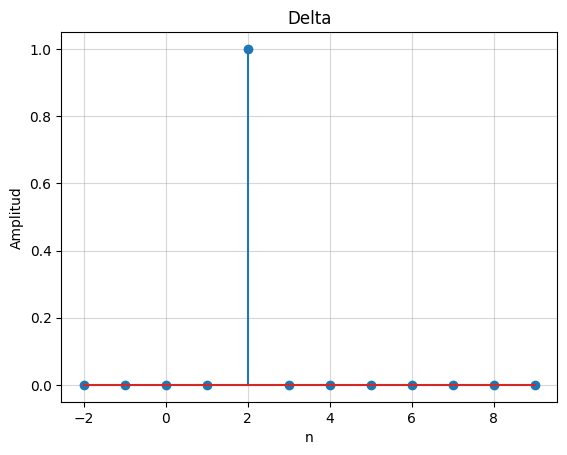

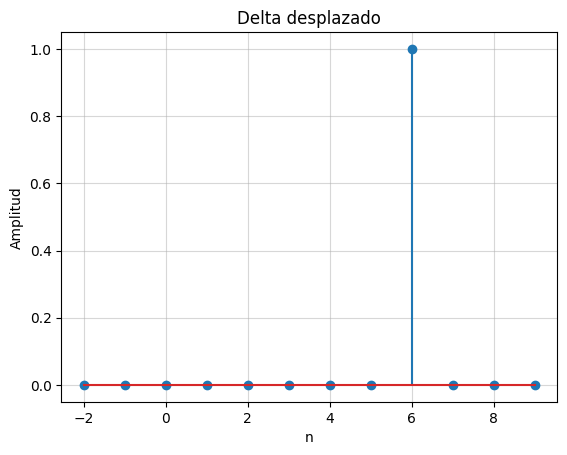

In [7]:
# Implementa una señal impulso desplazada

rango1  = np.arange(-2,10) # considerando como posición n°1 = -2
delta = signal.unit_impulse(len(rango1),4) #crea el impulso desde scipy

plt.stem(rango1, delta) #plot para señales discretas
plt.title("Delta")
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.show()

desplazar_delta = 8  #cambiar este valor para desplazar a delta en el tiempo 
delta_desplazado = signal.unit_impulse(len(rango1),desplazar_delta)

plt.stem(rango1, delta_desplazado)
plt.title("Delta desplazado")
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.show()

### 4.2 Verificación de Nyquist
Demuestra qué sucede cuando la frecuencia de muestreo $f_s$ es menor, igual o mayor a $2 \cdot F_{max}$.

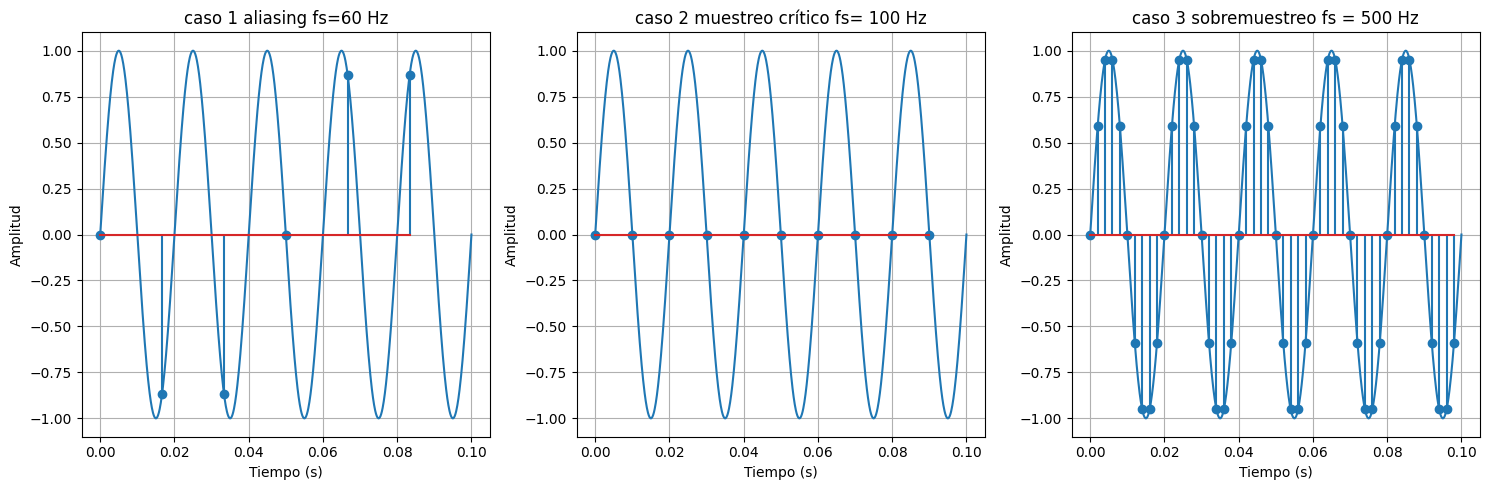

In [85]:
# Evalúa 3 casos de muestreo para una senoidal de 50Hz
f_max = 50
muestras1 = 1000
t= 0.1
rango2 = np.linspace(0, t, muestras1)
senoidal = np.sin(2*np.pi*f_max*rango2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# f_s = 60Hz (Aliasing)
f_s1 = 60
muestreo1 = np.arange(0, t, 1/f_s1)
senoidal1 = np.sin(2*np.pi*f_max*muestreo1)
axes[0].plot(rango2, senoidal)
axes[0].stem(muestreo1, senoidal1) 
axes[0].set_title("caso 1 aliasing fs=60 Hz")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

# f_s = 100Hz (Muestreo crítico)
f_s2=100
muestreo2 = np.arange(0, t, 1/f_s2)
senoidal2 = np.sin(2*np.pi*f_max*muestreo2)
axes[1].plot(rango2, senoidal)
axes[1].stem(muestreo2, senoidal2) 
axes[1].set_title("caso 2 muestreo crítico fs= 100 Hz")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Amplitud")
axes[1].grid(True)

# f_s = 500Hz (Sobremuestreo)
f_s3= 500
muestreo3 = np.arange(0, t, 1/f_s3)
senoidal3 = np.sin(2*np.pi*f_max*muestreo3)
axes[2].plot(rango2, senoidal)
axes[2].stem(muestreo3, senoidal3) 
axes[2].set_title("caso 3 sobremuestreo fs = 500 Hz")
axes[2].set_xlabel("Tiempo (s)")
axes[2].set_ylabel("Amplitud")
axes[2].grid(True)

plt.tight_layout()
plt.show()





## 5. Cuantización y Resolución de Bits
Simularemos el proceso de discretización en amplitud.

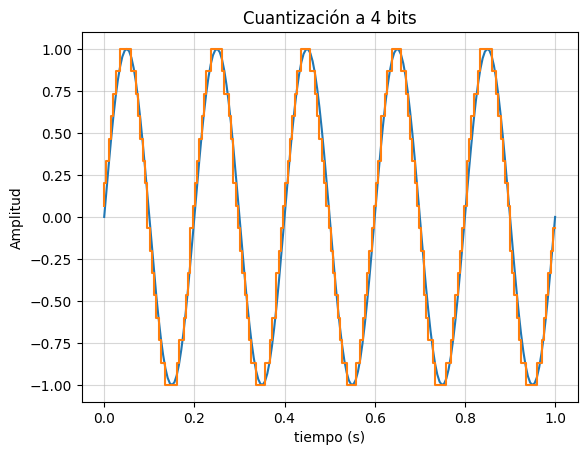

SNR del error de cuantización a 4 bits: 25.60 dB


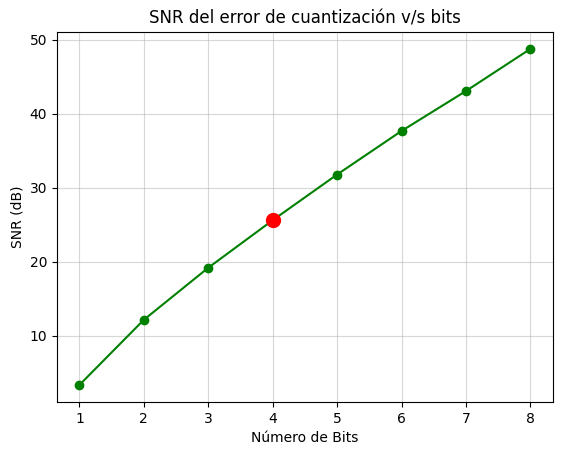

 De los gráficos se observa que a más bits hay menos error, aumentar la cantidad de bits aumenta exponencialmente los niveles de cuantización. 
Esto hace que los ´escalones´ del gráfico de la cuantización de la señal se vuelvan más pequeños, lo cual reduce el error de cuantización.
Si se considerara una señal aperiodica el error sería mayor.
 Al graficar el SNR en dB versus la cantidad de bits, se obtiene una recta ascendente. Lo cual confirma que la relación entre cantidad de bits y calidad del 
SNR es directamente proporcional. Además se observa el valor fijo del SNR en 4 bits solicitado


In [12]:
# Toma una señal y cuantízala a 4 bits (16 niveles).

#señal
f_senal = 5
f_s = 200
rango3 = np.linspace(0, 1, f_s)
senal = np.sin(2 * np.pi * f_senal * rango3)

#cuantizacion
bits= 4
cant_niv=2**bits #cantidad de niveles:16 
posicion = np.round((senal - np.min(senal)) / (np.max(senal) - np.min(senal)) * (cant_niv - 1)) #normaliza al entero mas cercano (idea obtenida de ayudantía)
senal_cuant = posicion * (np.max(senal) - np.min(senal)) / (cant_niv - 1) + np.min(senal) 

plt.plot(rango3,senal)
plt.step(rango3,senal_cuant)
plt.title('Cuantización a 4 bits')
plt.xlabel('tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.show()

# Calcula y grafica el SNR (Signal-to-Noise Ratio) del error de cuantización.

#aviso uso de IA: se usó el mismo codigo anterior, pero se creó una nueva variable vectorizada que permite aceptar múltiples bits
#para poder graficar el SNR sin problemas de dimensiones

bits_nuevo= np.arange(1, 9).reshape(-1, 1) #IA en esta linea
cant_niv=2**bits_nuevo #cantidad de niveles:16 

posicion = np.round((senal - np.min(senal)) / (np.max(senal) - np.min(senal)) * (cant_niv - 1)) #normaliza al entero mas cercano (idea obtenida de ayudantía)
senal_cuant = posicion * (np.max(senal) - np.min(senal)) / (cant_niv - 1) + np.min(senal) 

error_cuant = senal-senal_cuant # para obtener las potencias de las señales 
p_senal = np.mean(senal**2)  #por definicion de SNR se usa la potencia de la señal y la potencia del ruido
p_ruido = np.mean(error_cuant**2, axis=1)
snr = 10*np.log10(p_senal/ p_ruido) #en dB
snr_4bits = float(snr[3]) #IA: se saca el valor de 4 bits en la posición "3" para plotearlo y anotarlo en pantalla con print

print(f"SNR del error de cuantización a 4 bits: {snr_4bits:.2f} dB")

plt.plot(bits_nuevo.flatten(), snr, marker='o', color='green')
plt.plot(4, snr_4bits, marker='o', color='red', markersize=10, label=f'Punto 4 bits: {snr_4bits:.2f} dB')
plt.title('SNR del error de cuantización v/s bits')
plt.xlabel('Número de Bits')
plt.ylabel('SNR (dB)')
plt.grid(True, alpha=0.5)
plt.show()

print(" De los gráficos se observa que a más bits hay menos error, aumentar la cantidad de bits aumenta exponencialmente los niveles de cuantización. \n" \
"Esto hace que los ´escalones´ del gráfico de la cuantización de la señal se vuelvan más pequeños, lo cual reduce el error de cuantización.\n"
"Si se considerara una señal aperiodica el error sería mayor.\n "
"Al graficar el SNR en dB versus la cantidad de bits, se obtiene una recta ascendente. Lo cual confirma que la relación entre cantidad de bits y calidad del \n"
"SNR es directamente proporcional. Además se observa el valor fijo del SNR en 4 bits solicitado")



## 6. Análisis de Vibraciones: Caso de Ingeniería
Un motor gira a 60 Hz (rotación normal) pero tiene una falla de desalineación que genera un componente de 120 Hz. El entorno tiene mucho ruido.

**Tarea:**
1. Genera la señal mixta ruidosa.
2. Identifica las frecuencias mediante la FFT.

Frecuencias identificadas mediante FFT en gráfica: 60 y 120 Hz


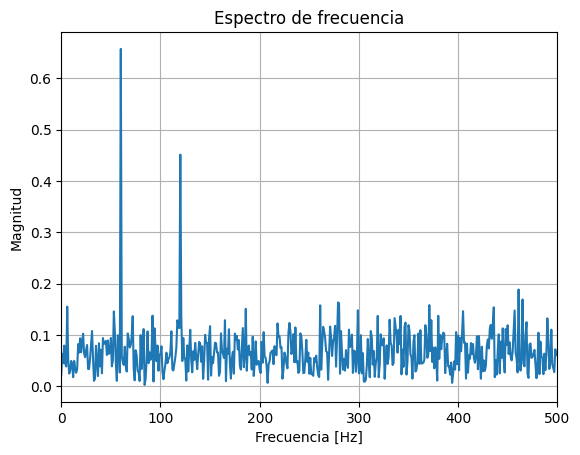

In [6]:
fs = 1000
t = np.linspace(0, 1, fs)
f_rotation = 60
f_fault = 120

# Señal con ruido blanco gaussiano
signal_clean = 0.7 * np.sin(2 * np.pi * f_rotation * t) + 0.4 * np.sin(2 * np.pi * f_fault * t)
noisy_signal = signal_clean + np.random.normal(0, 1.2, len(t))

# Cálculo FFT obtenido en las referencias de scipy (tutorial FFT)
N = len(t)
yf = fft(noisy_signal)
xf = fftfreq(N, 1/fs)[:N//2] # se dejan solo las frecuencias positivas

print(f"Frecuencias identificadas mediante FFT en gráfica: 60 y 120 Hz")

#obtenido de explicación de ayudantía: se obtienen nuevamente solo las frecuencias positivas, se calcula su magnitud y se normaliza con 2/N
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2])) 
plt.xlim(0, 500) 
plt.title("Espectro de frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.show()


## 7. Frecuencia Espacial en Imágenes
Las imágenes también tienen frecuencias. Cambios rápidos (bordes) son altas frecuencias; áreas suaves son bajas frecuencias.

**Tarea:**
1. Genera una rejilla senoidal (sinusoidal grating).
2. Aplica la FFT 2D y observa el espectro centrado.

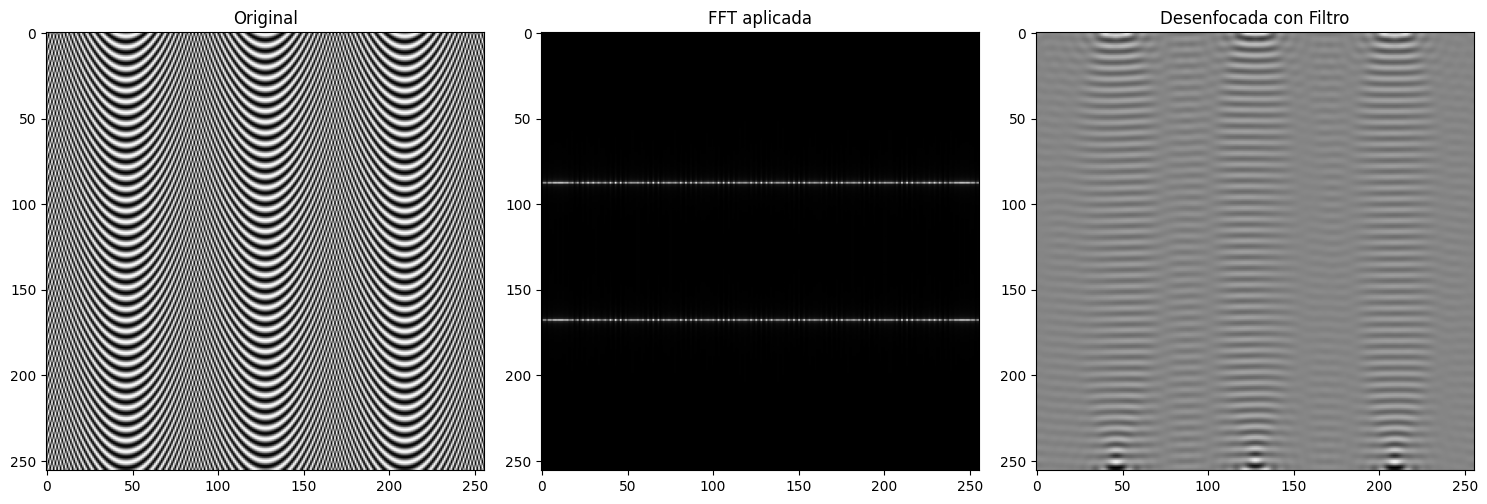

In [ ]:
# 1. Generar rejilla senoidal 2D (np.meshgrid).
x = np.linspace(-5, 5, 256)
y = np.linspace(-5, 5, 256)
X, Y = np.meshgrid(x, y)
imagen_z = np.sin(2 * np.pi * 4*(X**2 + Y)) 

# 2. Calcular FFT2 y aplicar fftshift.
Fz = fft2(imagen_z)
Fz_shifted = fftshift(Fz) # Centra el componente de frecuencia cero (DC)

# 3. Implementar un filtro de paso bajo circular para desenfocar una imagen de prueba.

x1 = np.linspace(-128, 128, 256)
y1 = np.linspace(-128, 128, 256)
X1, Y1 = np.meshgrid(x1, y1)

desenfoque = 40 #si este numero aumenta, la imagen se desenfoca menos y viceversa.

filtro_pb_circular = (X1**2 + Y1**2) <= desenfoque**2    #guiado por el tutorial para aplicar ecuaciones en 2D con meshgrid 

imagen_desenfocada = np.real(ifft2(ifftshift(Fz_shifted * filtro_pb_circular))) #segun referencias: "transformada inversa de Fourier para recuperar la imagen original"

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(imagen_z, cmap='gray'); ax[0].set_title('Original')
ax[1].imshow(np.abs(Fz_shifted), cmap='gray'); ax[1].set_title('FFT aplicada') # se plotean solo las frecuencias positivas
ax[2].imshow(imagen_desenfocada, cmap='gray'); ax[2].set_title('Desenfocada con Filtro')

plt.tight_layout()
plt.show()


## 8. Conclusiones y Preguntas Teóricas
- ¿Cómo afecta la desviación estándar del ruido gaussiano a la legibilidad del espectro en la FFT?

La legibilidad del espectro en la FFT se ve directamente relacionada con la desviación estándar del ruido gaussiano, ya que, si esta aumenta el ruido también lo hace, lo cual dificulta la distinción de los peaks de la señal que realmente sirven versus a los que provienen del ruido.

Ejemplificando, sería como en el ejercicio 6 del presente trabajo, los peaks de 60 y 120 Hz se hicieran más pequeños y se confundieran con los peaks que tienen menor magnitud, dificultando el análisis del resultado de la transformada.


- Explica por qué un cambio brusco de color en una imagen (un borde) genera componentes de alta frecuencia en el espectro 2D.

Los componentes de alta frecuencia en el espectro 2D generados por un cambio brusco de color en nuna imagen se justifican porque primeramente cualquier imagen se entiende como la suma de varias ondas/rejillas, las cuales siendo ondas de baja frecuencia se ven representadas con cambios suaves en una imagen, por lo que para generar un cambio brusco en una imagen, es necesario sumar ondas que oscilen muy rápido, lo cual se refiere a las frecuencias altas mencionadas.

(capitulos 24.1 y 24.2 de Python Programming And Numerical Methods)


- ¿Qué relación existe entre la resolución de cuantización y el rango dinámico de un sistema de audio?

Existe una relación directa entre el rango dinámico de un sistema de audio y la resolución de cuantización, la cuantización, como se pudo ver en el ejercicio 5 del presente trabajo, define los "escalones" que se ven gráficamente que se usan para obtener el error y SNR al redondearlos con la señal original. Ahora, considerando un SNR alto, también indicará un mayor rango dinámico del sistema, ya que, el sistema que se esté utilizando será capaz de captar mayores variaciones en el sonido sin que se pierdan.

## 9. Referencias

[Generate colors of noise in Python] https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python

[Generación de señales] https://medium.com/@martinkarlsson.io/fourier-transform-in-python-f15b3243ce9a

[Fourier Transform] https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.04-FFT-in-Python.html

[SciPy] https://docs.scipy.org/doc/scipy/tutorial/fft.html

[Fourier con numpy] https://towardsdatascience.com/fourier-transform-the-practical-python-implementation-acdd32f1b96a

[Sobre Teorema del sampleo] https://ipython-books.github.io/chapter-10-signal-processing/

[Sobre Matplotlib] https://matplotlib.org/stable/gallery/mplot3d/2dcollections3d.html

[2D meshing] https://thepythoncodingbook.com/2021/08/30/2d-fourier-transform-in-python-and-fourier-synthesis-of-images/

[Numerical Methods] https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html